In [1]:
# Директория

import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("kkhubiev/russian-financial-news")

def directory_tree(path):
    print(f"Структура директории: {path}\n")
    for root, dirs, files in os.walk(path):
        lvl = root.replace(path, '').count(os.sep)   
        folder_name = os.path.basename(root)
        if folder_name:
            print(f"{'  ' * lvl} {folder_name}/")
        for i, f in enumerate(files):
            print(f"{'   ' * (lvl + 1)} {f}")

directory_tree(path)

/home/alexey/fin_ml_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Структура директории: /home/alexey/.cache/kagglehub/datasets/kkhubiev/russian-financial-news/versions/3

 3/
   RussianFinancialNews/
       tickers_description.json
       news_collection.parquet
       preview.csv
     news_descriptions/
          news_descriptions_GPT4o.json
          news_description_LLama3_8b.json
          news_collection_old.parquet
     candles_data/
       1d/
             open.csv
             close.csv
             low.csv
             high.csv
             volume.csv
             value.csv
       10m/
             open.csv
             close.csv
             low.csv
             high.csv
             value.csv
       1h/
             open.csv
             close.csv
             low.csv
             high.csv
             volume.csv
             value.csv


In [2]:
#Основная инфа по таблице

parquet_path = os.path.join(path, "RussianFinancialNews", "news_collection.parquet")

df = pd.read_parquet(parquet_path, engine='fastparquet')

print(f"Количество строк и столбцов: {df.shape}")
print("\nНазвания столбцов и типы данных:")
print(df.dtypes)

display(df.sample(10))

Количество строк и столбцов: (91955, 6)

Названия столбцов и типы данных:
title     object
body      object
date      object
time      object
tags      object
source    object
dtype: object


,title,body,date,time,tags,source
0,Сбербанк. Нужен подтверждающий сигнал,Итоги торгов $$$ В пятницу акции Сбербанка под...,2021-02-19 00:00:00,not stated,Сбербанк,bcs_tech
0,no title,Добыча золота на Чукотке за 8 месяцев снизилас...,2022-10-11,not stated,no tags,smart_lab
0,no title,""" 01.09.2022 Главное: • WSJ: страны G7 на это...",2022-09-01,06:30:00,['morning'],rdv
0,Московская биржа. У сопротивления взяли паузу,На прошлой торговой сессии акции Московской би...,2023-11-24 00:00:00,not stated,Московская Биржа,bcs_tech
0,Мнение аналитиков. О редомициляции Ozon,Акционеры Ozon рассмотрят вопрос редомициляции...,2024-11-26 00:00:00,10:13,['OZON адр (Мосбиржа)'],bcs
0,no title,Акции Polymetal Int прекратят обращение на Лон...,2023-08-01,not stated,no tags,smart_lab
0,no title,Власти Москвы предлагают обязать застройщиков ...,2023-12-26,not stated,no tags,smart_lab
0,no title,СД - Лензолото: ДИВИДЕНДЫ = 1 184 (Одна тысяч...,2024-11-13,not stated,no tags,smart_lab
0,no title,""" ЦБ готов понижать ключевую ставку? Эльвира ...",2024-01-30,08:57:37,['новости'],t_invest
0,Самолет меняет генерального директора,На место Андрея Иваненко назначена финдиректор...,2024-11-18 00:00:00,12:59,['Самолет'],bcs


In [3]:
# Файл с тикерами

import json

json_path = os.path.join(path, "RussianFinancialNews", "tickers_description.json")

with open(json_path, 'r', encoding='utf-8') as f:
    tickers_dict = json.load(f)

print(f"Всего тикеров: {len(tickers_dict)}")

for i, (key, value) in enumerate(tickers_dict.items()):
    if i >= 5: break
    print(f"Тикер: {key}")
    print(f"Значение: {value}\n")

Всего тикеров: 238
Тикер: ABIO
Значение: Артген биотех (ранее Институт Стволовых Клеток Человека ПАО «ИСКЧ» — биотехнологическая компания, целью которой является создание, разработка и внедрение в практическое здравоохранение инновационных препаратов, изделии? или методов лечения, диагностики и профилактики, которые дают новые, более эффективные чем существующие, средства для борьбы с заболеваниями человека. В состав группы входят компании на разных этапах развития —от посевнои? стадии до стадии ранненего роста и зрелости

Тикер: ABRD
Значение: Завод шампанских вин «Абрау-Дюрсо» — крупнейший в России производитель, выпускающий игристое вино, как по классической технологии шампанизации, так и резервуарным методом. В 2007 году получает статус открытого акционерного общества, которое в 2015 году было преобразовано в публичное акционерное общество. Располагается в посёлке Абрау-Дюрсо Краснодарского края.

Тикер: AFKS
Значение: АФК «Система» является одной из самых крупных российских публич

In [4]:
# Убираем новости без тикеров
invalid_tags = ['[]', 'no tags', 'not stated']
df_filtered = df[~df['tags'].isin(invalid_tags)].copy()

# Объединяем заголовок и текст новости в один признак
df_filtered['title'] = df_filtered['title'].replace('no title', '')
df_filtered['full_text'] = df_filtered['title'] + ' ' + df_filtered['body']

# Стандартизируем дату + оставляем только дни
df_filtered['date'] = pd.to_datetime(df_filtered['date'], errors='coerce').dt.normalize()
df_filtered = df_filtered.dropna(subset=['date'])

print(f"Строк до фильтрации: {df.shape[0]}")
print(f"Строк после фильтрации: {df_filtered.shape[0]}")

display(df_filtered.sample(5))

Строк до фильтрации: 91955
Строк после фильтрации: 20196


,title,body,date,time,tags,source,full_text
0,«Лента» планирует с 4 мая делистинг расписок с...,«Лента» уведомила Deutsche Bank Trust Company ...,2023-03-31,not stated,['Лента ао'],finam,«Лента» планирует с 4 мая делистинг расписок с...
0,FESCO добавила новый порт судозахода по Deep Sea,"Компания добавила заход в порт Мундра, и тепер...",2023-05-23,not stated,['ДВМП ао'],finam,FESCO добавила новый порт судозахода по Deep S...
0,Совет директоров «Диасофта» рассматривает заяв...,Заседание СД было запланировано на 26 января,2024-01-26,not stated,['iДиасофт'],finam,Совет директоров «Диасофта» рассматривает заяв...
0,Продажи ЛСР за 9 месяцев снизились на 21%,Стоимость заключенных новых договоров достигла...,2024-10-18,not stated,['ЛСР ао'],finam,Продажи ЛСР за 9 месяцев снизились на 21% Стои...
0,"Правительство утвердило список программ, обяза...","В списке, в частности, продукты «Яндекса» и «ВК»",2024-07-26,not stated,"['МКПАО ВК', 'ЯНДЕКС']",finam,"Правительство утвердило список программ, обяза..."


In [5]:
# Достаём тикеры

valid_tickers = list(tickers_dict.keys())

manual_map = {
    'сбербанк': 'SBER',
    'сбер': 'SBER',
    'яндекс': 'YNDX',
    'газпром': 'GAZP',
    'лукойл': 'LKOH',
    'роснефть': 'ROSN',
    'втб': 'VTBR',
    'норникель': 'GMKN',
    'магнит': 'MGNT',
    'аэрофлот': 'AFLT',
    'система': 'AFKS'
}

def extract_ticker(tag):
    tag = str(tag)
    if tag in ['[]', 'no tags', 'not stated', 'None', 'nan']:
        return None
    
    for ticker in valid_tickers:
        if ticker in tag:
            return ticker
            
    tag = tag.lower()
    for rus_name, ticker in manual_map.items():
        if rus_name in tag:
            return ticker
            
    return None

df_filtered['ticker'] = df_filtered['tags'].apply(extract_ticker)

df_clean = df_filtered.dropna(subset=['ticker']).copy()

print(f"Новостей с чистым тикером осталось: {df_clean.shape[0]}")
print(f"Различных тикеров: {df_clean['ticker'].nunique()}")
print("\nТоп компаний по новостям:")
print(df_clean['ticker'].value_counts().head(10))
display(df_clean.sample(5))

Новостей с чистым тикером осталось: 3871
Различных тикеров: 69

Топ компаний по новостям:
ticker
GAZP    1026
SBER     583
YNDX     371
AFLT     332
LKOH     292
VTBR     251
ROSN     201
MGNT     130
MDMG     102
AFKS      98
Name: count, dtype: int64


,title,body,date,time,tags,source,full_text,ticker
0,"Сокращение инвестпрограммы ""Газпрома"" позитивн...",Сокращение ненужных инвестиций увеличивает сво...,2023-10-25,not stated,['ГАЗПРОМ ао'],finam,"Сокращение инвестпрограммы ""Газпрома"" позитивн...",GAZP
0,ВТБ купит у «Роснефти» судостроительный завод ...,Сделка находится на ранней стадии,2024-02-12,not stated,"['Роснефть', 'ВТБ ао']",finam,ВТБ купит у «Роснефти» судостроительный завод ...,ROSN
0,,""" Роснефть (ROSN): 11% дивдоходности и потенци...",2022-07-29,08:57:24,['ROSN'],rdv,""" Роснефть (ROSN): 11% дивдоходности и потенц...",ROSN
0,MDMG планирует вернуться к выплате дивидендов ...,По итогам 1 квартала компания уже выплатила 10...,2024-07-31,not stated,['MDMGао'],finam,MDMG планирует вернуться к выплате дивидендов ...,MDMG
0,Российский рынок утром растет вслед за ценами ...,Бумаги ВТБ снижаются после распоряжения Путина...,2024-10-10,not stated,"['ВТБ ао', 'CNYRUBTOM', 'Si', 'Brent', 'Si SiZ...",finam,Российский рынок утром растет вслед за ценами ...,VTBR


In [6]:
# Загружаем цены закрытия

close_prices_path = os.path.join(path, "RussianFinancialNews", "candles_data", "1d", "close.csv")
#open_prices_path = os.path.join(path, "RussianFinancialNews", "candles_data", "1d", "open.csv")
prices_df = pd.read_csv(close_prices_path)
#prices_open_df = pd.read_csv(open_prices_path)
display(prices_df.head(5))
#display(prices_open_df.head(5))

prices_df['begin'] = pd.to_datetime(prices_df['begin']).dt.normalize()
prices_df.set_index('begin', inplace=True)
display(prices_df.head(5))

# Считаем процентное изменение цены для всех тикеров
returns_df = prices_df.pct_change()

print(f"Размер таблицы: {returns_df.shape}")
display(returns_df.head())

,begin,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
0,2022-07-01,56.28,171.5,NaN,14.850,26.74,872.0,18660,66.24,21.220,...,NaN,107.00,NaN,0.282,0.2785,170.0,82.5,NaN,2920,3.500
1,2022-07-04,56.90,173.0,NaN,15.000,27.12,854.4,18422,64.55,21.895,...,NaN,109.50,NaN,0.283,0.2785,172.0,83.0,NaN,3010,3.480
2,2022-07-05,56.38,172.5,NaN,15.000,28.26,837.2,17902,64.99,21.500,...,NaN,109.20,NaN,0.273,0.2680,170.0,82.5,NaN,2950,3.470
3,2022-07-06,60.68,172.0,NaN,15.163,27.34,843.8,18088,64.96,21.325,...,NaN,107.70,NaN,0.273,0.2580,NaN,82.5,NaN,2985,3.550
4,2022-07-07,58.70,172.5,NaN,15.051,27.78,860.0,18402,65.35,21.375,...,NaN,110.45,NaN,0.269,0.2650,172.0,83.0,NaN,2900,3.605


,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,56.28,171.5,NaN,14.850,26.74,872.0,18660,66.24,21.220,NaN,...,NaN,107.00,NaN,0.282,0.2785,170.0,82.5,NaN,2920,3.500
2022-07-04,56.90,173.0,NaN,15.000,27.12,854.4,18422,64.55,21.895,NaN,...,NaN,109.50,NaN,0.283,0.2785,172.0,83.0,NaN,3010,3.480
2022-07-05,56.38,172.5,NaN,15.000,28.26,837.2,17902,64.99,21.500,NaN,...,NaN,109.20,NaN,0.273,0.2680,170.0,82.5,NaN,2950,3.470
2022-07-06,60.68,172.0,NaN,15.163,27.34,843.8,18088,64.96,21.325,NaN,...,NaN,107.70,NaN,0.273,0.2580,NaN,82.5,NaN,2985,3.550
2022-07-07,58.70,172.5,NaN,15.051,27.78,860.0,18402,65.35,21.375,NaN,...,NaN,110.45,NaN,0.269,0.2650,172.0,83.0,NaN,2900,3.605


Размер таблицы: (553, 252)


,ABIO,ABRD,ACKO,AFKS,AFLT,AGRO,AKRN,ALRS,AMEZ,APRI,...,WUSH,YAKG,YDEX,YKEN,YKENP,YRSB,YRSBP,ZAYM,ZILL,ZVEZ
begin,,,,,,,,,,,,,,,,,,,,,
2022-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-07-04,0.011016,0.008746,NaN,0.010101,0.014211,-0.020183,-0.012755,-0.025513,0.031810,NaN,...,NaN,0.023364,NaN,0.003546,0.000000,0.011765,0.006061,NaN,0.030822,-0.005714
2022-07-05,-0.009139,-0.002890,NaN,0.000000,0.042035,-0.020131,-0.028227,0.006816,-0.018041,NaN,...,NaN,-0.002740,NaN,-0.035336,-0.037702,-0.011628,-0.006024,NaN,-0.019934,-0.002874
2022-07-06,0.076268,-0.002899,NaN,0.010867,-0.032555,0.007883,0.010390,-0.000462,-0.008140,NaN,...,NaN,-0.013736,NaN,0.000000,-0.037313,NaN,0.000000,NaN,0.011864,0.023055
2022-07-07,-0.032630,0.002907,NaN,-0.007386,0.016094,0.019199,0.017360,0.006004,0.002345,NaN,...,NaN,0.025534,NaN,-0.014652,0.027132,NaN,0.006061,NaN,-0.028476,0.015493


In [7]:
# Добавляем столбцы с изменением цены на следующий день + направление (0, 1)

target_data = []

for index, row in df_clean.iterrows():
    ticker = row['ticker']
    date = row['date']
    
    # Цена тикера на следующий день
    try:
        if ticker in returns_df.columns:
            target_data.append(returns_df.loc[date:][ticker].iloc[1])
        else:
            target_data.append(None)
    except:
        target_data.append(None)

df_clean['target_return'] = target_data

df_final = df_clean.dropna(subset=['target_return']).copy()

# 1 если цена выросла, 0 если упала
df_final['label'] = (df_final['target_return'] > 0).astype(int)

# Сортировка по дате
df_final = df_final.sort_values('date')
display(df_final.head(5))

print(f"Итоговое число новостей: {len(df_final)}")
print("Распределение классов:")
print(df_final['label'].value_counts(normalize=True))

,title,body,date,time,tags,source,full_text,ticker,target_return,label
0,GAIL ограничила отпуск газа клиентам из-за неп...,"Уточняется, что GAIL сократила поставки на нек...",2022-01-08,not stated,['ГАЗПРОМ ао'],finam,GAIL ограничила отпуск газа клиентам из-за неп...,GAZP,-0.032468,0
0,"Чистая прибыль ""ЛУКОЙЛа"" по РСБУ за 1 полугоди...",Выручка в январе-июне удвоилась,2022-01-08,not stated,['ЛУКОЙЛ'],finam,"Чистая прибыль ""ЛУКОЙЛа"" по РСБУ за 1 полугоди...",LKOH,0.001395,1
0,"""Газпром"" за 7 месяцев снизил добычу на 12%",Экспорт в страны дальнего зарубежья снизился н...,2022-01-08,not stated,['ГАЗПРОМ ао'],finam,"""Газпром"" за 7 месяцев снизил добычу на 12% Эк...",GAZP,-0.032468,0
0,MDMG не исключает выплаты дивидендов до конца ...,Выручка MDMG за 1 полугодие 2022 года выросла ...,2022-01-08,not stated,['MDMGао'],finam,MDMG не исключает выплаты дивидендов до конца ...,MDMG,0.020253,1
0,Выручка MDMG за 1 полугодие 2022 года выросла ...,Сопоставимая выручка (LFL) группы осталась на ...,2022-01-08,not stated,['MDMGао'],finam,Выручка MDMG за 1 полугодие 2022 года выросла ...,MDMG,0.020253,1


Итоговое число новостей: 3103
Распределение классов:
label
0    0.543023
1    0.456977
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_final['full_text']
y = df_final['label']

# 80% тренировка, 20% тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# игнорируем в случае, если меньше 5 раз за всю историю и слишком частые
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print(f"Train новости: {X_train_vec.shape[0]}")
print(f"Test новости: {X_test_vec.shape[0]}")
print(f"Cлова-признаки: {X_train_vec.shape[1]}")

print("\nРандомные 15 слов:")
import random
words = vectorizer.get_feature_names_out()
print(random.sample(list(words), 15))

Train новости: 2482
Test новости: 621
Cлова-признаки: 2489

Рандомные 15 слов:
['приняли', 'расходы', '123', 'сроки', 'директора', 'добыча', 'дни', 'первого', 'энергетики', 'ек', 'рядом', 'предложение', 'говорят', '250', '500']


Accuracy: 0.5475

Подробно:
               precision    recall  f1-score   support

           0       0.59      0.65      0.62       352
           1       0.47      0.42      0.44       269

    accuracy                           0.55       621
   macro avg       0.53      0.53      0.53       621
weighted avg       0.54      0.55      0.54       621



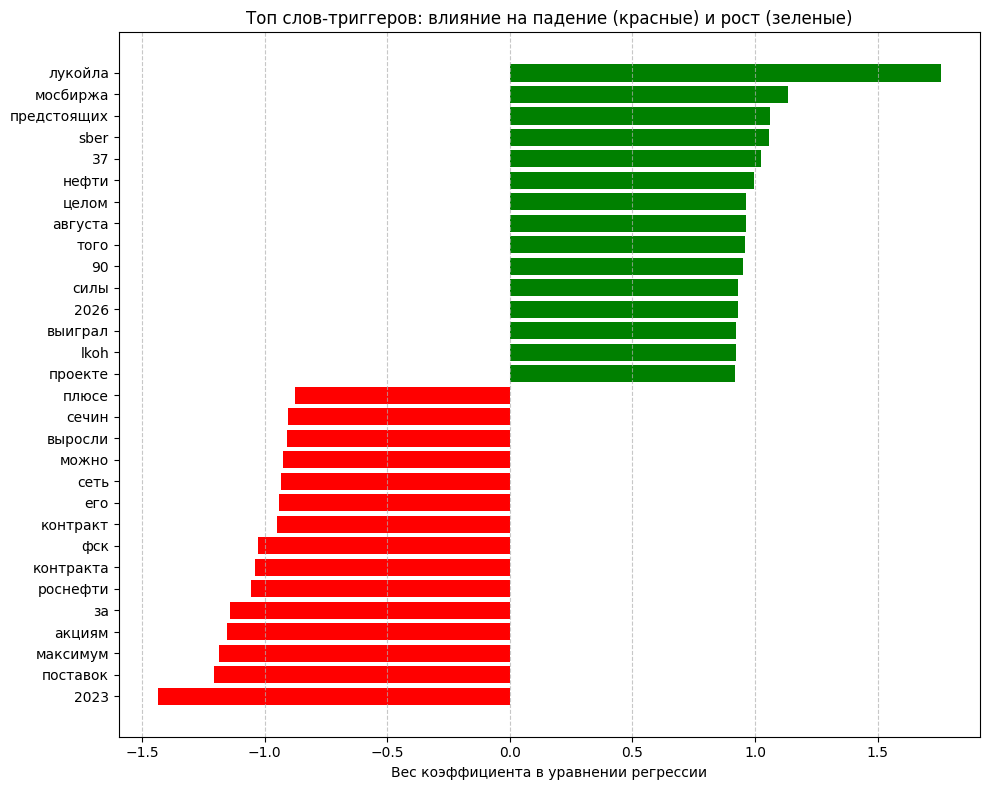

In [9]:
# Обучение логистической регрессии

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
print("\nПодробно:\n", classification_report(y_test, predictions))

# Визуализация

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

# Топ слов для падения и топ для роста
top_pos = np.argsort(coefs)[-15:]
top_neg = np.argsort(coefs)[:15]

# Объединяем для графика
top_indices = np.concatenate([top_neg, top_pos])
top_features = feature_names[top_indices]
top_coefs = coefs[top_indices]

plt.figure(figsize=(10, 8))
colors = ['red' if c < 0 else 'green' for c in top_coefs]
plt.barh(top_features, top_coefs, color=colors)
plt.title('Топ слов-триггеров: влияние на падение (красные) и рост (зеленые)')
plt.xlabel('Вес коэффициента в уравнении регрессии')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# Смотрим на файл с оценкой chatgpt4

gpt_json_path = os.path.join(path, "RussianFinancialNews", "news_descriptions", "news_descriptions_GPT4o.json")

with open(gpt_json_path, 'r', encoding='utf-8') as f:
    gpt_data = json.load(f)
    
print(f"Количество новостей: {len(gpt_data)}\n")
print(json.dumps(gpt_data[list(gpt_data.keys())[0]], indent=2, ensure_ascii=False))

Количество новостей: 15000

{
  "thinking": "The article discusses Gazprom's production figures, highlighting a discrepancy between gas and oil revenue, and mentioning potential market changes in Russia's energy strategy. This is a financial report as it concerns company performance metrics (revenue figures) and an upcoming policy decision that could affect the gas market.",
  "article_type": "finance",
  "country": [
    "Russia"
  ],
  "sectors": [
    "Energy"
  ],
  "tickers": [
    "GAZP"
  ],
  "sentiment_score": -0.5
}


In [11]:

gpt_df = pd.DataFrame.from_dict(gpt_data, orient='index')
gpt_df.index = gpt_df.index.astype(int)

# 2. Проверяем пересечение!
# Берем индексы нашего финального датасета (df_final) и ищем их в gpt_df
common_indices = df_final.index.intersection(gpt_df.index)

print(f"Из {len(df_final)} наших новостей с таргетом, GPT-4 успел разметить: {len(common_indices)} штук.")

# 3. Если пересечение есть, посмотрим на случайный пример
if len(common_indices) > 0:
    sample_idx = common_indices[0]
    print("\n--- Проверка совпадения ---")
    print("Текст нашей новости:")
    print(df_final.loc[sample_idx, 'full_text'][:200] + "...")
    print("\nРазметка GPT:")
    print(f"Тикер: {gpt_df.loc[sample_idx, 'tickers']}")
    print(f"Сентимент: {gpt_df.loc[sample_idx, 'sentiment_score']}")
else:
    print("\nУвы, индексы не совпали. Придется искать другой путь объединения.")

Из 3103 наших новостей с таргетом, GPT-4 успел разметить: 2 штук.

--- Проверка совпадения ---
Текст нашей новости:
0    GAIL ограничила отпуск газа клиентам из-за неп...
0    Чистая прибыль "ЛУКОЙЛа" по РСБУ за 1 полугоди...
0    "Газпром" за 7 месяцев снизил добычу на 12% Эк...
0    MDMG не исключает выплаты дивидендов до конца ...
0    Выручка MDMG за 1 полугодие 2022 года выросла ...
                           ...                        
0     "️ Глава Международного энергетического агент...
0     "Может ли Россия остановить поставки газа в Е...
0     " Остановка поставок газа в Европу также помо...
0     "Газпром (GAZP) поставляет в Европу в 3 раза ...
0     " Пока Газпром (GAZP) снижает поставки в Евро...
Name: full_text, Length: 200, dtype: object

Разметка GPT:
Тикер: ['GAZP']
Сентимент: -0.5


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Объединяем наши цены (df_final) и оценки нейросети (gpt_df) по совпавшим индексам
# how='inner' означает, что мы оставляем ТОЛЬКО те 525 строк, которые есть в обеих таблицах
df_vip = df_final.join(gpt_df[['sentiment_score', 'thinking']], how='inner')

# 2. Очищаем от возможных пустых значений
df_vip = df_vip.dropna(subset=['sentiment_score', 'label'])

# 3. Пишем наше простое правило: если сентимент больше 0, значит ждем рост
df_vip['gpt_prediction'] = (df_vip['sentiment_score'] > 0).astype(int)

# 4. Считаем метрики
acc_gpt = accuracy_score(df_vip['label'], df_vip['gpt_prediction'])

print(f"Размер VIP-выборки: {len(df_vip)}")
print(f"Точность предсказаний GPT-4: {round(acc_gpt, 4)}\n")
print("Подробный отчет GPT-4:")
print(classification_report(df_vip['label'], df_vip['gpt_prediction']))

# Выведем пример, где GPT-4 ошиблась (это всегда самое интересное)
errors = df_vip[df_vip['label'] != df_vip['gpt_prediction']]
if len(errors) > 0:
    print("\n--- Пример ошибки GPT-4 ---")
    sample_error = errors.iloc[0]
    print(f"Текст: {sample_error['full_text'][:150]}...")
    print(f"Сентимент GPT: {sample_error['sentiment_score']} -> Прогноз: {sample_error['gpt_prediction']}")
    print(f"Реальность рынка (label): {sample_error['label']}")

Размер VIP-выборки: 3102
Точность предсказаний GPT-4: 0.5432

Подробный отчет GPT-4:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      1684
           1       1.00      0.00      0.00      1418

    accuracy                           0.54      3102
   macro avg       0.77      0.50      0.35      3102
weighted avg       0.75      0.54      0.38      3102


--- Пример ошибки GPT-4 ---
Текст: Чистая прибыль "ЛУКОЙЛа" по РСБУ за 1 полугодие 2022 года выросла в 3,6 раза Выручка в январе-июне удвоилась...
Сентимент GPT: -0.5 -> Прогноз: 0
Реальность рынка (label): 1


In [13]:
import json
import pandas as pd
import os

# Путь к файлу
llama_json_path = os.path.join(path, "RussianFinancialNews", "news_descriptions", "news_description_LLama3_8b.json")

with open(llama_json_path, 'r', encoding='utf-8') as f:
    llama_data = json.load(f)

llama_df = pd.DataFrame.from_dict(llama_data, orient='index')

print("Доступные столбцы в таблице LLaMA:")
print(llama_df.columns.tolist())

print("\n--- Как выглядит первая запись ---")
# Достаем первый ключ и печатаем его содержимое
first_key = list(llama_data.keys())[0]
print(json.dumps(llama_data[first_key], indent=2, ensure_ascii=False))

Доступные столбцы в таблице LLaMA:
['thinking', 'description']

--- Как выглядит первая запись ---
{
  "thinking": "The article discusses the recent trend in Gazprom's oil and gas production, highlighting that despite a significant increase in natural gas extraction, the revenue from gas sales has decreased compared to oil sales. This could potentially impact Russia's energy market and the country's overall economy.",
  "description": {
    "article_type": "finance",
    "country": [
      "Russia"
    ],
    "sectors": [
      "Energy"
    ],
    "tickers": [
      "GAZP"
    ],
    "sentiment_score": -0.5
  }
}


In [14]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Собираем таблицу LLaMA с нуля и ПРИНУДИТЕЛЬНО делаем индексы числами
llama_df = pd.DataFrame.from_dict(llama_data, orient='index')
llama_df.index = llama_df.index.astype(int)

# 2. Распаковываем словарь из столбца description
description_df = llama_df['description'].apply(pd.Series)
llama_df_clean = pd.concat([llama_df.drop('description', axis=1), description_df], axis=1)

# 3. Делаем JOIN с нашей таблицей цен. Теперь типы совпадут!
df_vip_llama = df_final.join(llama_df_clean[['sentiment_score', 'thinking']], how='inner')

# 4. Превращаем сентимент в нормальные числа и удаляем пустоты
df_vip_llama['sentiment_score'] = pd.to_numeric(df_vip_llama['sentiment_score'], errors='coerce')
df_vip_llama = df_vip_llama.dropna(subset=['sentiment_score', 'label'])

# 5. Применяем наше правило: сентимент > 0 = рост (1)
df_vip_llama['llama_prediction'] = (df_vip_llama['sentiment_score'] > 0).astype(int)

# 6. Считаем метрики
acc_llama = accuracy_score(df_vip_llama['label'], df_vip_llama['llama_prediction'])

print(f"Размер VIP-выборки LLaMA: {len(df_vip_llama)}")
print(f"Точность предсказаний LLaMA: {round(acc_llama, 4)}\n")
print("Подробный отчет LLaMA:")
print(classification_report(df_vip_llama['label'], df_vip_llama['llama_prediction']))

Размер VIP-выборки LLaMA: 3102
Точность предсказаний LLaMA: 0.5432

Подробный отчет LLaMA:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      1684
           1       1.00      0.00      0.00      1418

    accuracy                           0.54      3102
   macro avg       0.77      0.50      0.35      3102
weighted avg       0.75      0.54      0.38      3102



In [15]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Работаем только с пересечением данных (827 строк)
# Сортируем по дате, чтобы не заглядывать в будущее!
df_ensemble = df_vip_llama.sort_values('date').copy()

# 2. Делим на Train и Test (80% / 20%)
X_text_train, X_text_test, X_sent_train, X_sent_test, y_train, y_test = train_test_split(
    df_ensemble['full_text'], 
    df_ensemble['sentiment_score'], 
    df_ensemble['label'], 
    test_size=0.2, 
    shuffle=False
)

# 3. Векторизуем текст (обучаем словарь только на Train)
# Делаем max_features поменьше, так как строк мало, чтобы не переобучиться
ensemble_vectorizer = TfidfVectorizer(max_features=1000, min_df=3, max_df=0.8)
X_text_train_vec = ensemble_vectorizer.fit_transform(X_text_train)
X_text_test_vec = ensemble_vectorizer.transform(X_text_test)

# 4. Добавляем колонку сентимента к матрице слов
# Превращаем Series в двумерный массив (N, 1) для стыковки
import numpy as np
X_sent_train_reshaped = np.array(X_sent_train).reshape(-1, 1)
X_sent_test_reshaped = np.array(X_sent_test).reshape(-1, 1)

# hstack - функция SciPy для склеивания разреженных матриц
X_train_final = hstack([X_text_train_vec, X_sent_train_reshaped])
X_test_final = hstack([X_text_test_vec, X_sent_test_reshaped])

# 5. Обучаем Логистическую регрессию
model_ensemble = LogisticRegression(random_state=42, max_iter=1000)
model_ensemble.fit(X_train_final, y_train)

# 6. Оцениваем
predictions_ensemble = model_ensemble.predict(X_test_final)
acc_ensemble = accuracy_score(y_test, predictions_ensemble)

print(f"Размер обучающей выборки: {X_train_final.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test_final.shape[0]} строк")
print(f"Всего признаков: {X_train_final.shape[1]} (слова + 1 сентимент)")
print(f"\nТочность АНСАМБЛЯ (TF-IDF + LLaMA): {round(acc_ensemble, 4)}\n")
print(classification_report(y_test, predictions_ensemble))

# Посмотрим, какой вес алгоритм дал сентименту от LLaMA
# Сентимент у нас приклеен последним столбцом, значит его вес - последний в массиве
print(f"Вес признака LLaMA (sentiment_score): {round(model_ensemble.coef_[0][-1], 4)}")

Размер обучающей выборки: 2481 строк
Размер тестовой выборки: 621 строк
Всего признаков: 1001 (слова + 1 сентимент)

Точность АНСАМБЛЯ (TF-IDF + LLaMA): 0.5491

              precision    recall  f1-score   support

           0       0.60      0.61      0.61       352
           1       0.48      0.47      0.47       269

    accuracy                           0.55       621
   macro avg       0.54      0.54      0.54       621
weighted avg       0.55      0.55      0.55       621

Вес признака LLaMA (sentiment_score): 0.6337


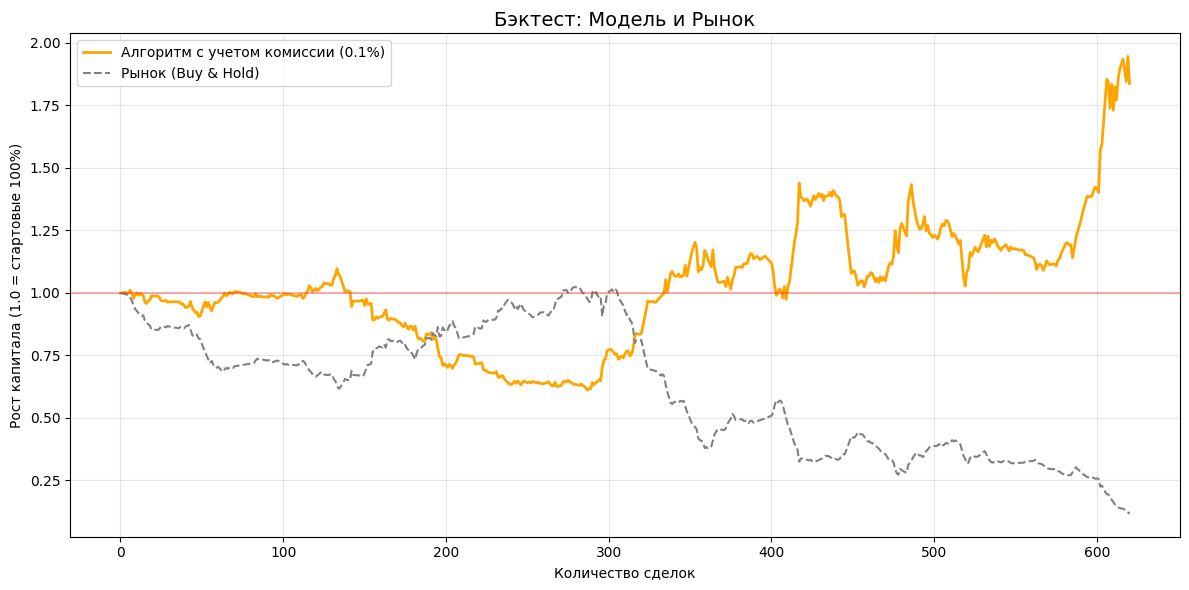

Стартовый капитал: 1.0 (100%)
Итоговый капитал алгоритма: 1.8373
Чистая прибыль алгоритма: 83.73%
Чистая прибыль рынка за то же время: -88.45%


In [16]:
# Бэктест логистической регрессии (с комиссией рынка)

_, actual_returns = train_test_split(
    df_final['target_return'], test_size=0.2, shuffle=False
)

signals = np.where(predictions == 1, 1, -1)

commission_rate = 0.001  

returns = signals * actual_returns.values - commission_rate

# Расчёт накопленного капитала
equity_curve_net = (1 + returns).cumprod()
benchmark = (1 + actual_returns.values).cumprod()

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(equity_curve_net, label='Алгоритм с учетом комиссии (0.1%)', color='orange', linewidth=2)
plt.plot(benchmark, label='Рынок (Buy & Hold)', color='gray', linestyle='--')

plt.title('Бэктест: Модель и Рынок', fontsize=14)
plt.xlabel('Количество сделок')
plt.ylabel('Рост капитала (1.0 = стартовые 100%)')
plt.axhline(y=1.0, color='red', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Стартовый капитал: 1.0 (100%)")
print(f"Итоговый капитал алгоритма: {round(equity_curve_net[-1], 4)}")
print(f"Чистая прибыль алгоритма: {round((equity_curve_net[-1] - 1) * 100, 2)}%")
print(f"Чистая прибыль рынка за то же время: {round((benchmark[-1] - 1) * 100, 2)}%")

In [17]:
# Тремнруем RandomForest и градиентный бустинг

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    df_final['full_text'], df_final['label'], test_size=0.2, shuffle=False
)

vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Обучение случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vec, y_train)
rf_predictions = rf_model.predict(X_test_vec)
rf_acc = accuracy_score(y_test, rf_predictions)

# Обучение Градиентного Бустинга
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_vec, y_train)
gb_predictions = gb_model.predict(X_test_vec)
gb_acc = accuracy_score(y_test, gb_predictions)

print(f"Логистическая Регрессия: 54.75%")
print(f"Случайный Лес: {round(rf_acc * 100, 2)}%")
print(f"Градиентный Бустинг: {round(gb_acc * 100, 2)}%")

Логистическая Регрессия: 54.75%
Случайный Лес: 53.62%
Градиентный Бустинг: 55.56%


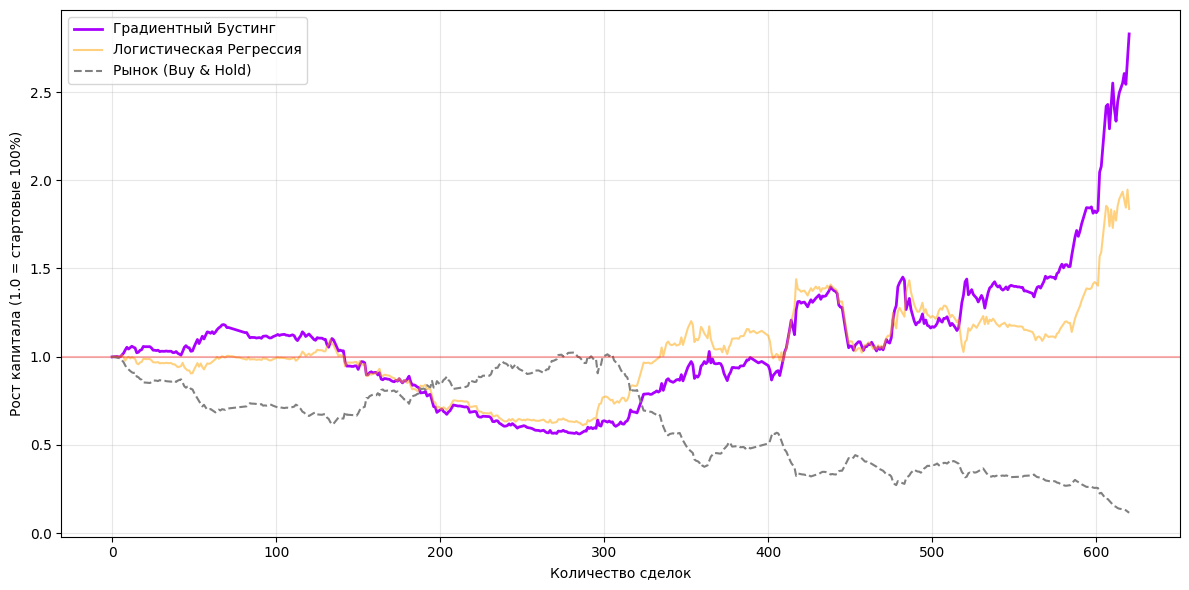

Чистая прибыль Регрессии: 83.73%
Чистая прибыль Бустинга:   182.91%


In [18]:
# Бэктест гб и сравнение с лог регрессией

signals_gb = np.where(gb_predictions == 1, 1, -1)

commission_rate = 0.001  
returns_gb = signals_gb * actual_returns.values - commission_rate

equity_curve_gb = (1 + returns_gb).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(equity_curve_gb, label='Градиентный Бустинг', color='#aa00ff', linewidth=2)
plt.plot(equity_curve_net, label='Логистическая Регрессия', color='orange', alpha=0.5)
plt.plot(benchmark, label='Рынок (Buy & Hold)', color='gray', linestyle='--')

plt.xlabel('Количество сделок')
plt.ylabel('Рост капитала (1.0 = стартовые 100%)')
plt.axhline(y=1.0, color='red', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Чистая прибыль Регрессии: {round((equity_curve_net[-1] - 1) * 100, 2)}%")
print(f"Чистая прибыль Бустинга:   {round((equity_curve_gb[-1] - 1) * 100, 2)}%")

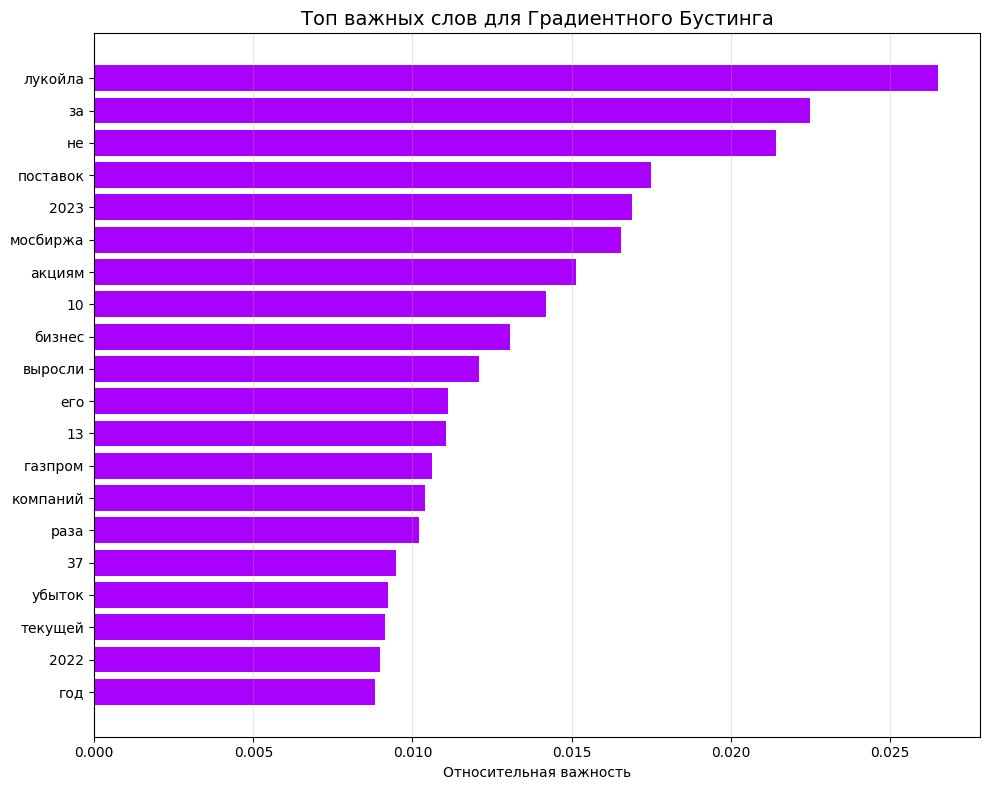

In [19]:
# Самые важные слова для gb

feature_names = vectorizer.get_feature_names_out()

importances = gb_model.feature_importances_

feature_df = pd.DataFrame({
    'Word': feature_names,
    'Importance': importances
})

top_features = feature_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Word'][::-1], top_features['Importance'][::-1], color='#aa00ff')

plt.title('Топ важных слов для Градиентного Бустинга', fontsize=14)
plt.xlabel('Относительная важность')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from t_tech.invest.sandbox.client import SandboxClient
from t_tech.invest import MoneyValue

TOKEN = "t.SN_FuMuZ_pQg_BrSv8OtVEI8SrMhTxR2ATV6rz1S3lD7Ta5FI12qHhVwDCA9foQl2NfAdiTidgqcg6oN5_y67A"

def setup_sandbox_account():
    with SandboxClient(TOKEN) as client:
        sandbox_account = client.sandbox.open_sandbox_account()
        account_id = sandbox_account.account_id
        print(f"ID счета: {account_id}")
        
        client.sandbox.sandbox_pay_in(
            account_id=account_id,
            amount=MoneyValue(currency="rub", units=100000, nano=0)
        )
        
        portfolio = client.operations.get_portfolio(account_id=account_id)
        rubles = portfolio.total_amount_currencies.units
        money = portfolio.total_amount_portfolio
        print(f"Баланс портфеля: {money}")

setup_sandbox_account()

e753633b5cfa5c0038043b5c1519dc3f OpenSandboxAccount INVALID_ARGUMENT 35001


RequestError: (<StatusCode.INVALID_ARGUMENT: (3, 'invalid argument')>, '35001', Metadata(tracking_id='e753633b5cfa5c0038043b5c1519dc3f', ratelimit_limit='200, 200;w=60', ratelimit_remaining=199, ratelimit_reset=5, message='Sandbox accounts limit reached'))

In [ ]:
import uuid
from t_tech.invest.sandbox.client import SandboxClient
from t_tech.invest import OrderType, OrderDirection

TOKEN = "t.SN_FuMuZ_pQg_BrSv8OtVEI8SrMhTxR2ATV6rz1S3lD7Ta5FI12qHhVwDCA9foQl2NfAdiTidgqcg6oN5_y67A"
ACCOUNT_ID = "b2c674a8-8361-4f05-b0e6-d183be56f07b"

SBER_FIGI = "BBG004730N88"

def test_buy():
    try:
        with SandboxClient(TOKEN) as client:
            order_response = client.orders.post_order(
                figi=SBER_FIGI,
                quantity=1,
                account_id=ACCOUNT_ID,
                direction=OrderDirection.ORDER_DIRECTION_BUY,
                order_type=OrderType.ORDER_TYPE_MARKET,
                order_id=str(uuid.uuid4())
            )
            
            print(f"Заявка исполнена Статус: {order_response.execution_report_status.name}")
            
            portfolio = client.operations.get_portfolio(account_id=ACCOUNT_ID)
            print("\nПортфель:")
            for position in portfolio.positions:
                print(f"Инструмент (FIGI): {position.figi}, Количество: {position.quantity.units}")
                
    except Exception as e:
        print(f"Ошибка заявки: {e}")

test_buy()

Заявка исполнена Статус: EXECUTION_REPORT_STATUS_FILL

Портфель:
Инструмент (FIGI): RUB000UTSTOM, Количество: 99675
Инструмент (FIGI): BBG004730N88, Количество: 1


In [ ]:
def process_news_and_trade(news_text: str, figi: str):
    print(f"Новость: '{news_text}'")
    
    text_vector = vectorizer.transform([news_text])
    
    prediction = gb_model.predict(text_vector)[0]
    
    direction = None
    action_str = ""
    
    if prediction == 1:
        direction = OrderDirection.ORDER_DIRECTION_BUY
        action_str = "BUY"
    elif prediction == 0:
        direction = OrderDirection.ORDER_DIRECTION_SELL
        action_str = "SELL"
        
    print(f"Результат: {prediction} Сигнал: {action_str}")
    
    try:
        with SandboxClient(TOKEN) as client:
            order_response = client.orders.post_order(
                figi=figi,
                quantity=1,
                account_id=ACCOUNT_ID,
                direction=direction,
                order_type=OrderType.ORDER_TYPE_MARKET,
                order_id=str(uuid.uuid4())
            )
            print(f"Статус: {order_response.execution_report_status.name}")
            
    except Exception as e:
        print(e)


p_news = "Сбербанк отчитался о рекордной чистой прибыли и утвердил выплату высоких дивидендов за прошедший год."
process_news_and_trade(p_news, SBER_FIGI)

n_news = "Введены новые жесткие санкции, бизнес несет непредвиденные убытки, руководство отменяет дивиденды."
process_news_and_trade(n_news, SBER_FIGI)

Новость: 'Сбербанк отчитался о рекордной чистой прибыли и утвердил выплату высоких дивидендов за прошедший год.'
Результат: 0 Сигнал: SELL


None PostOrder RESOURCE_EXHAUSTED 


Статус: EXECUTION_REPORT_STATUS_FILL
Новость: 'Введены новые жесткие санкции, бизнес несет непредвиденные убытки, руководство отменяет дивиденды.'
Результат: 1 Сигнал: BUY
(<StatusCode.RESOURCE_EXHAUSTED: (8, 'resource exhausted')>, '', Metadata(tracking_id=None, ratelimit_limit='2, 2;w=1', ratelimit_remaining=0, ratelimit_reset=1, message=None))


In [ ]:
import joblib

joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(gb_model, 'gradient_boosting_model.pkl')

['gradient_boosting_model.pkl']

In [11]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cpu")
model_name = "blanchefort/rubert-base-cased-sentiment"

print("Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Загрузка модели...")
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval() # КРИТИЧЕСКИ ВАЖНО для мощных моделей

def debug_blanchefort(text):
    print("\n--- Анализ текста ---")
    
    # 1. Проверяем токенизатор (видит ли он русские слова?)
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 10): {tokens[:10]}")
    
    # 2. Подготовка тензоров
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt').to(device)
    
    # 3. Прогон через модель
    with torch.no_grad():
        outputs = model(**inputs)
    
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].tolist()
    
    # Для blanchefort классы: 0 - Neutral, 1 - Positive, 2 - Negative
    result = {
        'neutral': round(probabilities[0], 4),
        'positive': round(probabilities[1], 4),
        'negative': round(probabilities[2], 4)
    }
    print(f"Результат: {result}")
    return result

# Берем радикально разные тексты
# test_1 = "Инвесторы в панике из-за неожиданного решения Газпрома полностью отказаться от выплаты дивидендов. Акции рухнули."
# test_2 = "Сбербанк шокировал рынок, объявив о рекордных выплатах! Акции стремительно переписали максимумы на эйфории."

# debug_blanchefort(test_1)
# debug_blanchefort(test_2)

# Тест
test_news_1 = "Инвесторы в панике из-за неожиданного решения совета директоров Газпрома полностью отказаться от выплаты дивидендов за прошлый год. На фоне этих новостей акции компании рухнули на открытии торгов, потянув за собой весь индекс."
print(debug_blanchefort(test_news_1))
test_news_2 = "Сбербанк буквально шокировал рынок, объявив о рекордных дивидендных выплатах, которые вдвое превысили самые смелые прогнозы аналитиков! Акции стремительно переписали исторические максимумы на фоне эйфории инвесторов"
print(debug_blanchefort(test_news_2))
test_news_3 = "Совет директоров ПАО Татнефть рекомендовал выплатить промежуточные дивиденды за третий квартал в размере 35 рублей на одну обыкновенную акцию в соответствии с утвержденной дивидендной политикой."
print(debug_blanchefort(test_news_3))
test_news_4 = "Магнит утвердил дивиденды в размере 120 рублей на акцию. Тем не менее, участники рынка отреагировали на новость с явным разочарованием, поскольку консенсус-прогноз предполагал выплату не менее 300 рублей"
print(debug_blanchefort(test_news_4))


Загрузка токенизатора...
Загрузка модели...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1631.60it/s]



--- Анализ текста ---
Токены (первые 10): ['Ин', '##весто', '##ры', 'в', 'панике', 'из', '-', 'за', 'неожиданного', 'решения']
Результат: {'neutral': 0.1807, 'positive': 0.0679, 'negative': 0.7515}
{'neutral': 0.1807, 'positive': 0.0679, 'negative': 0.7515}

--- Анализ текста ---
Токены (первые 10): ['Сбербанк', 'буквально', 'шоки', '##ровал', 'рынок', ',', 'объявив', 'о', 'рекорд', '##ных']
Результат: {'neutral': 0.1812, 'positive': 0.068, 'negative': 0.7508}
{'neutral': 0.1812, 'positive': 0.068, 'negative': 0.7508}

--- Анализ текста ---
Токены (первые 10): ['Совет', 'директоров', 'ПАО', 'Та', '##т', '##неф', '##ть', 'рекомендовал', 'выплатить', 'промежуточные']
Результат: {'neutral': 0.1806, 'positive': 0.0678, 'negative': 0.7516}
{'neutral': 0.1806, 'positive': 0.0678, 'negative': 0.7516}

--- Анализ текста ---
Токены (первые 10): ['Магнит', 'утвердил', 'дивиденды', 'в', 'размере', '120', 'рублей', 'на', 'акцию', '.']
Результат: {'neutral': 0.1807, 'positive': 0.0678, 'negative':

In [12]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cpu")

# Берем мощного кандидата
model_name = "seara/rubert-base-cased-russian-sentiment"

print("Загрузка токенизатора и модели (seara)...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

# КРИТИЧЕСКИ ВАЖНО: режим оценки
model.eval()

def test_seara_sentiment(text):
    inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].tolist()
    
    # Динамически достаем правильные названия классов (чтобы не было путаницы)
    labels = model.config.id2label
    result = {labels[i]: round(prob, 4) for i, prob in enumerate(probabilities)}
    
    return result

# Наши 4 теста
test_news_1 = "Инвесторы в панике из-за неожиданного решения совета директоров Газпрома полностью отказаться от выплаты дивидендов за прошлый год. На фоне этих новостей акции компании рухнули на открытии торгов, потянув за собой весь индекс."
print("Тест 1 (Паника):", test_seara_sentiment(test_news_1))

test_news_2 = "Сбербанк буквально шокировал рынок, объявив о рекордных дивидендных выплатах, которые вдвое превысили самые смелые прогнозы аналитиков! Акции стремительно переписали исторические максимумы на фоне эйфории инвесторов"
print("Тест 2 (Эйфория):", test_seara_sentiment(test_news_2))

test_news_3 = "Совет директоров ПАО Татнефть рекомендовал выплатить промежуточные дивиденды за третий квартал в размере 35 рублей на одну обыкновенную акцию в соответствии с утвержденной дивидендной политикой."
print("Тест 3 (Сухой факт):", test_seara_sentiment(test_news_3))

test_news_4 = "Магнит утвердил дивиденды в размере 120 рублей на акцию. Тем не менее, участники рынка отреагировали на новость с явным разочарованием, поскольку консенсус-прогноз предполагал выплату не менее 300 рублей"
print("Тест 4 (Разочарование):", test_seara_sentiment(test_news_4))

Загрузка токенизатора и модели (seara)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1649.38it/s]


Тест 1 (Паника): {'neutral': 0.3034, 'positive': 0.0134, 'negative': 0.6832}
Тест 2 (Эйфория): {'neutral': 0.2027, 'positive': 0.3977, 'negative': 0.3996}
Тест 3 (Сухой факт): {'neutral': 0.9237, 'positive': 0.0499, 'negative': 0.0264}
Тест 4 (Разочарование): {'neutral': 0.8386, 'positive': 0.0306, 'negative': 0.1307}


In [1]:
import json
import pandas as pd
import re

# Функция для склейки текста из сложных структур Телеграма
def extract_text(text_obj):
    if isinstance(text_obj, str):
        return text_obj
    elif isinstance(text_obj, list):
        # Если это кусок текста - берем его, если хэштег/ссылка - достаем по ключу 'text'
        return "".join([t if isinstance(t, str) else t.get('text', '') for t in text_obj])
    return ""

file_path = 'result.json'
print("Читаем файл...")

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

messages = data.get('messages', [])
parsed_data = []

# Жесткий фильтр по хэштегу
keyword = '#дивиденд'

for msg in messages:
    if msg.get('type') == 'message':
        raw_text = msg.get('text', '')
        clean_text = extract_text(raw_text)
        
        # Проверяем наличие хэштега (в нижнем регистре на всякий случай)
        if keyword in clean_text.lower():
            
            # Достаем дату и время
            datetime_str = msg.get('date', '')
            if 'T' in datetime_str:
                date_part, time_part = datetime_str.split('T')
            else:
                date_part, time_part = "1970-01-01", "00:00:00"
            
            # БОНУС: Пытаемся вытащить тикер (все слова, начинающиеся с # или $, кроме #дивиденд)
            # MarketTwits часто пишет #UPRO или $UPRO
            tickers = re.findall(r'[#$]([A-Za-z0-9]+)', clean_text)
            tickers = [t.upper() for t in tickers if t.lower() != 'дивиденд' and t.lower() != 'новости']
            main_ticker = tickers[0] if tickers else None
                
            parsed_data.append({
                'date': date_part,
                'time': time_part,
                'ticker': main_ticker,  # Сохраняем тикер для будущего поиска графиков!
                'text': clean_text.strip(),
                'message_id': msg.get('id', '')
            })

df = pd.DataFrame(parsed_data)

if not df.empty:
    # Удаляем пустые строки и сохраняем
    df.to_csv('dividends_news.csv', index=False, encoding='utf-8-sig')
    print(f"Успешно! Найдено постов про дивиденды: {len(df)}")
    
    # Покажем первые 5 строк, чтобы убедиться, что всё красиво
    display(df.head()) 
else:
    print("Не найдено подходящих постов.")

Читаем файл...
Успешно! Найдено постов про дивиденды: 6925


,date,time,ticker,text,message_id
0,2018-09-03,10:45:44,GAZP,"⚠️GAZP - CAPEX - ДИВИДЕНДЫ\n""Газпром"" может ...",15655
1,2018-09-04,16:37:58,NaN,"АКЦИИ РФ - ДИВИДЕНДЫ\n""БКС Глобал Маркетс"" о...",15756
2,2018-09-06,10:23:33,NaN,АКЦИИ РФ - ГОСКОМПАНИИ - ДИВИДЕНДЫ\nБАЗОВЫЙ ВА...,15913
3,2018-09-06,17:12:26,NMTP,NMTP - ДИВИДЕНДЫ\nСовет директоров НМТП рекоме...,15982
4,2018-09-07,12:08:35,GAZP,GAZP - ДИВИДЕНДЫ - БЮДЖЕТ РФ\nБюджет-2019 прое...,16049


In [4]:
import pandas as pd

# Загружаем наш сырой файл
df = pd.read_csv('dividends_news.csv')

print(f"Изначально строк: {len(df)}")

# 1. Оставляем только свежие новости (начиная с 2021 года)
df = df[df['date'] >= '2022-05-01']

# 2. Оставляем ТОЛЬКО российский рынок (ищем флаг 🇷🇺 в тексте)
df = df[df['text'].str.contains('🇷🇺', na=False)]

# 3. Убираем новости, где тикер почему-то не распознался
df = df[df['ticker'].notna()]

# Сбрасываем индексы после фильтрации
df = df.reset_index(drop=True)

print(f"Осталось ИДЕАЛЬНО чистых строк: {len(df)}")

# Сохраняем боевой датасет
df.to_csv('dividends_news_clean.csv', index=False, encoding='utf-8-sig')
display(df.head())

Изначально строк: 6925
Осталось ИДЕАЛЬНО чистых строк: 2857


,date,time,ticker,text,message_id
0,2022-05-02,18:05:57,OZON,⚠️🇷🇺#OZON #дивиденд\nOzon не планирует выплачи...,190905
1,2022-05-04,09:04:01,ETLN,⚠️🇷🇺#ETLN #дивиденд\nсд Эталон принял решение ...,191088
2,2022-05-04,14:24:32,AKRN,⚠️🇷🇺#AKRN #дивиденд\nсд Акрон рекомендовал не...,191161
3,2022-05-04,15:07:01,LSNG,"⚡️🇷🇺#LSNG #дивиденд\n сд ""Ленэнерго"" рекомендо...",191171
4,2022-05-04,15:15:37,POSI,🇷🇺#POSI #дивиденд\nакционеры Позитив проголосо...,191173


In [6]:
import requests
import pandas as pd
from datetime import datetime, timedelta

def check_moex_reaction(ticker, news_date, news_time):
    print(f"Ищем данные для {ticker} в районе {news_date} {news_time}...")
    
    # Сдвигаем время, чтобы захватить окно торгов (до и после новости)
    dt = datetime.strptime(f"{news_date} {news_time}", "%Y-%m-%d %H:%M:%S")
    start_time = (dt - timedelta(minutes=30)).strftime("%H:%M:%S")
    end_time = (dt + timedelta(minutes=60)).strftime("%H:%M:%S")
    
    # API Московской биржи. interval=10 означает 10-минутные свечи
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/{ticker}/candles.json"
    params = {
        "from": f"{news_date} {start_time}",
        "till": f"{news_date} {end_time}",
        "interval": 10 
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Вытаскиваем нужные колонки (дата/время, цена открытия, закрытия, объем)
    columns = data['candles']['columns']
    values = data['candles']['data']
    
    if not values:
        print("Данных нет (возможно, новость вышла ночью или в выходной)")
        return None
        
    df = pd.DataFrame(values, columns=columns)
    df = df[['begin', 'open', 'close', 'volume']]
    
    print("\nСвечи с Московской биржи вокруг выхода новости:")
    display(df)
    
    return df

# Протестируем на новости №3 из твоего примера: Ленэнерго утвердило дивиденды
# 2022-05-04 15:07:01, LSNG, 21.22 руб на преф (хорошая новость)
check_moex_reaction('LSNGP', '2022-05-04', '15:07:01') 
# (Используем LSNGP, так как основная реакция в Ленэнерго всегда в префах)

Ищем данные для LSNGP в районе 2022-05-04 15:07:01...

Свечи с Московской биржи вокруг выхода новости:


,begin,open,close,volume
0,2022-05-04 14:40:00,141.65,141.00,1430
1,2022-05-04 14:50:00,141.35,152.15,225190
2,2022-05-04 15:00:00,152.10,153.00,225820
3,2022-05-04 15:10:00,152.95,152.20,150310
4,2022-05-04 15:20:00,152.25,151.65,94860
5,2022-05-04 15:30:00,151.60,150.35,107670
6,2022-05-04 15:40:00,150.35,150.50,36670
7,2022-05-04 15:50:00,150.70,151.20,44620
8,2022-05-04 16:00:00,151.15,151.45,44650


,begin,open,close,volume
0,2022-05-04 14:40:00,141.65,141.00,1430
1,2022-05-04 14:50:00,141.35,152.15,225190
2,2022-05-04 15:00:00,152.10,153.00,225820
3,2022-05-04 15:10:00,152.95,152.20,150310
4,2022-05-04 15:20:00,152.25,151.65,94860
5,2022-05-04 15:30:00,151.60,150.35,107670
6,2022-05-04 15:40:00,150.35,150.50,36670
7,2022-05-04 15:50:00,150.70,151.20,44620
8,2022-05-04 16:00:00,151.15,151.45,44650


In [7]:
import requests
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
import time
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

df = pd.read_csv('dividends_news_clean.csv')

# Создаем пустую колонку для будущих процентов
df['target_pct'] = None

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36'
}

# Функция для получения профита одной новости
def get_profit_for_news(ticker, date_str, time_str):
    try:
        dt = datetime.strptime(f"{date_str} {time_str}", "%Y-%m-%d %H:%M:%S")
        # Берем окно с запасом: от времени новости до +60 минут
        start_time = dt.strftime("%H:%M:%S")
        end_time = (dt + timedelta(minutes=60)).strftime("%H:%M:%S")
        
        url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/{ticker}/candles.json"
        params = {
            "from": f"{date_str} {start_time}",
            "till": f"{date_str} {end_time}",
            "interval": 10 # 10-минутные свечи
        }
        
        response = requests.get(url, params=params, headers=headers, verify=False, timeout=5)
        data = response.json()
        values = data.get('candles', {}).get('data', [])
        
        if not values or len(values) < 3:
            return None # Нет данных (выходной/вечер)
            
        # values[0] - это свеча, внутри которой вышла новость (наша цена входа по закрытию)
        entry_price = values[0][2] # индекс 2 это 'close'
        
        # values[2] - это закрытие свечи примерно через 20-30 минут (наша цена выхода)
        exit_price = values[2][2]
        
        # Считаем процент изменения
        pct_change = ((exit_price - entry_price) / entry_price) * 100
        return round(pct_change, 3)
        
    except Exception:
        return None

print("Начинаем скачивание котировок с Мосбиржи...")

# Используем tqdm для отображения прогресса
for index, row in tqdm(df.iterrows(), total=len(df)):
    ticker = str(row['ticker']).strip()
    date_str = row['date']
    time_str = row['time']
    
    profit = get_profit_for_news(ticker, date_str, time_str)
    df.at[index, 'target_pct'] = profit
    
    time.sleep(0.1) # Пауза 100мс, чтобы биржа не забанила

# Очищаем строки, для которых биржа не отдала данные (ночные посты и т.д.)
df_final = df.dropna(subset=['target_pct']).reset_index(drop=True)

# Сохраняем финальный датасет!
df_final.to_csv('dividends_ml_ready.csv', index=False, encoding='utf-8-sig')

print(f"\nГотово! Размечено новостей: {len(df_final)}")
display(df_final.head())

Начинаем скачивание котировок с Мосбиржи...


100%|██████████| 2857/2857 [18:12<00:00,  2.62it/s] 


Готово! Размечено новостей: 2465


,date,time,ticker,text,message_id,target_pct
0,2022-05-04,14:24:32,AKRN,⚠️🇷🇺#AKRN #дивиденд\nсд Акрон рекомендовал не...,191161,-0.023
1,2022-05-04,15:07:01,LSNG,"⚡️🇷🇺#LSNG #дивиденд\n сд ""Ленэнерго"" рекомендо...",191171,-1.75
2,2022-05-04,15:15:37,POSI,🇷🇺#POSI #дивиденд\nакционеры Позитив проголосо...,191173,-0.382
3,2022-05-06,17:57:34,UPRO,⚠️🇷🇺#UPRO #дивиденд\nсд Юнипро рекомендовал н...,191609,-0.5
4,2022-05-11,10:19:29,TATN,"🇷🇺#TATN #дивиденд #buyback\n""Татнефть"" отказа...",191952,-0.078


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import warnings

# Отключаем мелкие предупреждения
warnings.filterwarnings('ignore')

# 1. Загрузка данных
df = pd.read_csv('dividends_ml_ready.csv')

# 2. Создаем функцию для разметки (Порог 0.3%)
def get_class(pct):
    if pct > 0.3: return 1
    elif pct < -0.3: return -1
    else: return 0

df['target_class'] = df['target_pct'].apply(get_class)

print("Баланс классов во всем датасете:")
print(df['target_class'].value_counts())
print("-" * 30)

# 3. Сортировка по времени (КРИТИЧЕСКИ ВАЖНО ДЛЯ РЫНКА!)
df = df.sort_values(by=['date', 'time']).reset_index(drop=True)

# 4. Векторизация (превращаем текст в цифры)
# max_features=1500 (берем 1500 самых важных слов/фраз)
# ngram_range=(1,2) (ищем и одиночные слова, и пары слов)
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X = tfidf.fit_transform(df['text'])
y = df['target_class']

# 5. Хронологический сплит (80% на обучение, 20% на тест)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Обучающая выборка (прошлое): {X_train.shape[0]} новостей")
print(f"Тестовая выборка (будущее): {X_test.shape[0]} новостей")
print("-" * 30)

# 6. Обучение Градиентного Бустинга
print("Обучаем Градиентный Бустинг... (может занять 5-10 секунд)")
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 7. Экзамен! Предсказываем будущее
y_pred = model.predict(X_test)

print("\nОТЧЕТ О ТОЧНОСТИ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(classification_report(y_test, y_pred))

Баланс классов во всем датасете:
target_class
 0    1273
-1     843
 1     349
Name: count, dtype: int64
------------------------------
Обучающая выборка (прошлое): 1972 новостей
Тестовая выборка (будущее): 493 новостей
------------------------------
Обучаем Градиентный Бустинг... (может занять 5-10 секунд)

ОТЧЕТ О ТОЧНОСТИ МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ:
              precision    recall  f1-score   support

          -1       0.24      0.30      0.27       102
           0       0.71      0.73      0.72       339
           1       0.06      0.02      0.03        52

    accuracy                           0.57       493
   macro avg       0.34      0.35      0.34       493
weighted avg       0.55      0.57      0.56       493



In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import warnings

warnings.filterwarnings('ignore')

# 1. Загрузка и подготовка данных
df = pd.read_csv('dividends_ml_ready.csv')
df['target_class'] = df['target_pct'].apply(lambda x: 1 if x > 0.3 else (-1 if x < -0.3 else 0))
df = df.sort_values(by=['date', 'time']).reset_index(drop=True)

# 2. Инициализация ТВОЕЙ модели (seara)
device = torch.device("cpu") # Если есть GPU, можно поменять на "cuda"
model_name = "seara/rubert-base-cased-russian-sentiment"

print("Загрузка токенизатора и модели (seara)...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

# Функция из твоего кода, адаптированная для pandas
def get_seara_probs(text):
    try:
        inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].tolist()
        labels = model.config.id2label
        
        # Собираем словарь (приводим ключи к нижнему регистру для надежности)
        result = {labels[i].lower(): prob for i, prob in enumerate(probabilities)}
        
        # Возвращаем 3 вероятности (если какого-то ключа нет, вернет 0)
        return result.get('positive', 0.0), result.get('neutral', 0.0), result.get('negative', 0.0)
    except Exception:
        # Если текст кривой, возвращаем 100% нейтральность
        return 0.0, 1.0, 0.0

print("Прогоняем новости через нейросеть (это займет время!)...")
tqdm.pandas()

# Применяем твою модель ко всем текстам
df[['prob_pos', 'prob_neu', 'prob_neg']] = df['text'].progress_apply(
    lambda x: pd.Series(get_seara_probs(str(x)))
)

print("\nВекторизация текстов (TF-IDF)...")
# 3. Слияние признаков
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text'])
X_sentiment = csr_matrix(df[['prob_pos', 'prob_neu', 'prob_neg']].values)

# Склеиваем!
X_combined = hstack([X_tfidf, X_sentiment])
y = df['target_class']

# 4. Хронологический сплит (80/20)
split_index = int(len(df) * 0.8)
X_train, X_test = X_combined[:split_index], X_combined[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 5. Обучение Бустинга
print("Обучаем Градиентный Бустинг на объединенных данных...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("\nОТЧЕТ О ТОЧНОСТИ МОДЕЛИ (TF-IDF + SEARA):")
print(classification_report(y_test, y_pred))

Загрузка токенизатора и модели (seara)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 972.60it/s] 


Прогоняем новости через нейросеть (это займет время!)...


100%|██████████| 2465/2465 [03:15<00:00, 12.60it/s]



Векторизация текстов (TF-IDF)...
Обучаем Градиентный Бустинг на объединенных данных...

ОТЧЕТ О ТОЧНОСТИ МОДЕЛИ (TF-IDF + SEARA):
              precision    recall  f1-score   support

          -1       0.27      0.34      0.30       102
           0       0.73      0.73      0.73       339
           1       0.05      0.02      0.03        52

    accuracy                           0.58       493
   macro avg       0.35      0.37      0.35       493
weighted avg       0.56      0.58      0.57       493



In [4]:
import requests
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
import time
import urllib3
import warnings

warnings.filterwarnings('ignore')
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Берем наш изначальный чистый датасет текстов (без старых таргетов)
df = pd.read_csv('dividends_news_clean.csv')

# Создаем колонки для 4 разных таймфреймов
df['target_10m'] = None
df['target_20m'] = None
df['target_30m'] = None
df['target_1h'] = None

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36'
}

def get_multi_timeframe_profits(ticker, date_str, time_str):
    try:
        dt = datetime.strptime(f"{date_str} {time_str}", "%Y-%m-%d %H:%M:%S")
        start_time = dt.strftime("%H:%M:%S")
        # Берем окно 90 минут, чтобы точно захватить часовую свечу
        end_time = (dt + timedelta(minutes=90)).strftime("%H:%M:%S")
        
        url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/{ticker}/candles.json"
        params = {
            "from": f"{date_str} {start_time}",
            "till": f"{date_str} {end_time}",
            "interval": 10 # 10-минутные свечи
        }
        
        response = requests.get(url, params=params, headers=headers, verify=False, timeout=5)
        data = response.json()
        values = data.get('candles', {}).get('data', [])
        
        if not values or len(values) < 2:
            return None, None, None, None
            
        entry_price = values[0][2] # Закрытие текущей свечи (вход)
        
        # Безопасно достаем цены через 10, 20, 30 и 60 минут (если биржа еще работала)
        p_10m = round(((values[1][2] - entry_price) / entry_price) * 100, 3) if len(values) > 1 else None
        p_20m = round(((values[2][2] - entry_price) / entry_price) * 100, 3) if len(values) > 2 else None
        p_30m = round(((values[3][2] - entry_price) / entry_price) * 100, 3) if len(values) > 3 else None
        p_1h  = round(((values[6][2] - entry_price) / entry_price) * 100, 3) if len(values) > 6 else None
        
        return p_10m, p_20m, p_30m, p_1h
        
    except Exception:
        return None, None, None, None

print("Скачиваем котировки для 4 таймфреймов...")

for index, row in tqdm(df.iterrows(), total=len(df)):
    ticker = str(row['ticker']).strip()
    
    p10, p20, p30, p60 = get_multi_timeframe_profits(ticker, row['date'], row['time'])
    
    df.at[index, 'target_10m'] = p10
    df.at[index, 'target_20m'] = p20
    df.at[index, 'target_30m'] = p30
    df.at[index, 'target_1h'] = p60
    
    time.sleep(0.1)

# Очищаем только те строки, где нет даже 10-минутной реакции
df_final = df.dropna(subset=['target_10m']).reset_index(drop=True)

df_final.to_csv('dividends_multi_targets.csv', index=False, encoding='utf-8-sig')

print(f"\nГотово! Размечено новостей: {len(df_final)}")
display(df_final[['date', 'ticker', 'target_10m', 'target_20m', 'target_30m', 'target_1h']].head(10))

Скачиваем котировки для 4 таймфреймов...


100%|██████████| 2857/2857 [14:33<00:00,  3.27it/s] 



Готово! Размечено новостей: 2546


,date,ticker,target_10m,target_20m,target_30m,target_1h
0,2022-05-04,ETLN,0.0,-1.815,-2.954,None
1,2022-05-04,AKRN,-0.012,-0.023,-0.339,-0.152
2,2022-05-04,LSNG,-1.75,-1.75,-2.0,-3.0
3,2022-05-04,POSI,-0.064,-0.382,-0.276,-0.36
4,2022-05-06,UPRO,-0.357,-0.5,-0.572,None
5,2022-05-11,TATN,-0.339,-0.078,-0.13,-0.391
6,2022-05-11,SIBN,0.774,0.774,0.673,0.673
7,2022-05-11,GAZA,-1.515,None,None,None
8,2022-05-12,IRKT,-0.662,-0.993,-0.993,-0.911
9,2022-05-12,FESH,0.119,0.239,-0.089,-0.268


In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# 1. Загружаем наш мульти-таргет датасет
df = pd.read_csv('dividends_multi_targets.csv')
targets = ['target_10m', 'target_20m', 'target_30m', 'target_1h']

results = []

print("Запускаем турнир моделей (займет около 10 секунд)...\n")

for target in targets:
    # Берем только те строки, где есть данные для текущего таймфрейма
    df_target = df.dropna(subset=[target]).copy()
    
    # Разметка классов (порог 0.3%)
    df_target['class'] = df_target[target].apply(lambda x: 1 if x > 0.3 else (-1 if x < -0.3 else 0))
    
    # Сортировка по времени (защита от заглядывания в будущее)
    df_target = df_target.sort_values(by=['date', 'time']).reset_index(drop=True)
    
    # TF-IDF векторизация
    tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
    X = tfidf.fit_transform(df_target['text'])
    y = df_target['class']
    
    # Сплит 80/20
    split_index = int(len(df_target) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Обучение Градиентного Бустинга
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    
    # Предсказание
    y_pred = model.predict(X_test)
    
    # Вытаскиваем точность (Precision - % успешных сделок) 
    # и F1 (баланс) для лонга (1) и шорта (-1)
    prec_up = precision_score(y_test, y_pred, labels=[1], average='macro', zero_division=0)
    prec_down = precision_score(y_test, y_pred, labels=[-1], average='macro', zero_division=0)
    
    f1_up = f1_score(y_test, y_pred, labels=[1], average='macro', zero_division=0)
    f1_down = f1_score(y_test, y_pred, labels=[-1], average='macro', zero_division=0)
    
    results.append({
        'Таймфрейм': target.replace('target_', ''),
        'Точность: ЛОНГ (Рост)': round(prec_up, 2),
        'Точность: ШОРТ (Падение)': round(prec_down, 2),
        'F1-score: ЛОНГ': round(f1_up, 2),
        'F1-score: ШОРТ': round(f1_down, 2)
    })

# Выводим красивую итоговую таблицу
df_results = pd.DataFrame(results)
print("🏆 ИТОГИ: НА КАКОЙ МИНУТЕ РАБОТАЕТ СИГНАЛ? 🏆")
display(df_results)

Запускаем турнир моделей (займет около 10 секунд)...

🏆 ИТОГИ: НА КАКОЙ МИНУТЕ РАБОТАЕТ СИГНАЛ? 🏆


,Таймфрейм,Точность: ЛОНГ (Рост),Точность: ШОРТ (Падение),F1-score: ЛОНГ,F1-score: ШОРТ
0,10m,0.06,0.16,0.03,0.12
1,20m,0.09,0.27,0.03,0.31
2,30m,0.00,0.32,0.00,0.39
3,1h,0.18,0.39,0.04,0.50


In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import warnings

warnings.filterwarnings('ignore')

# 1. Загрузка и разметка часового таргета
df = pd.read_csv('dividends_multi_targets.csv')
df = df.dropna(subset=['target_1h']).copy()
df['class'] = df['target_1h'].apply(lambda x: 1 if x > 0.3 else (-1 if x < -0.3 else 0))
df = df.sort_values(by=['date', 'time']).reset_index(drop=True)

# 2. Инициализация твоей модели SEARA
device = torch.device("cpu")
model_name = "seara/rubert-base-cased-russian-sentiment"

print("Загрузка токенизатора и модели (seara)...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

def get_seara_probs(text):
    try:
        inputs = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].tolist()
        labels = model.config.id2label
        res = {labels[i].lower(): p for i, p in enumerate(probs)}
        return res.get('positive', 0.0), res.get('neutral', 0.0), res.get('negative', 0.0)
    except:
        return 0.0, 1.0, 0.0

print("Прогоняем тексты через нейросеть (ожидание ~3 минуты)...")
tqdm.pandas()
df[['prob_pos', 'prob_neu', 'prob_neg']] = df['text'].progress_apply(lambda x: pd.Series(get_seara_probs(str(x))))

# 3. Слияние признаков (TF-IDF + SEARA)
print("\nВекторизация текстов...")
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text'])
X_sentiment = csr_matrix(df[['prob_pos', 'prob_neu', 'prob_neg']].values)

X_combined = hstack([X_tfidf, X_sentiment])
y = df['class']

# 4. Хронологический сплит (80/20)
split_index = int(len(df) * 0.8)
X_train, X_test = X_combined[:split_index], X_combined[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 5. Обучение БАЗОВОГО Бустинга (БЕЗ ТЮНИНГА)
print("Обучаем базовый Градиентный Бустинг...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("\n=== ОТЧЕТ: ТАЙМФРЕЙМ 1 ЧАС + SEARA (БЕЗ ТЮНИНГА) ===")
print(classification_report(y_test, y_pred))

/home/alexey/fin_ml_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка токенизатора и модели (seara)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1182.99it/s]


Прогоняем тексты через нейросеть (ожидание ~3 минуты)...


100%|██████████| 2387/2387 [03:07<00:00, 12.76it/s]



Векторизация текстов...
Обучаем базовый Градиентный Бустинг...

=== ОТЧЕТ: ТАЙМФРЕЙМ 1 ЧАС + SEARA (БЕЗ ТЮНИНГА) ===
              precision    recall  f1-score   support

          -1       0.38      0.68      0.49       151
           0       0.58      0.48      0.53       240
           1       0.25      0.02      0.04        87

    accuracy                           0.46       478
   macro avg       0.40      0.40      0.35       478
weighted avg       0.46      0.46      0.43       478



In [2]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

print("Запускаем тюнинг гиперпараметров (GridSearch)...")
print("Перебираем десятки комбинаций. Это займет пару минут!\n")

# 1. Настраиваем сетку параметров для перебора
param_grid = {
    'n_estimators': [50, 100, 200],      # Количество деревьев
    'max_depth': [2, 3, 5],              # Глубина каждого дерева (насколько сложные правила он ищет)
    'learning_rate': [0.05, 0.1, 0.2]    # Шаг обучения
}

# 2. Хронологическая кросс-валидация (чтобы не заглядывать в будущее)
tscv = TimeSeriesSplit(n_splits=3)

# 3. Базовая модель
gb = GradientBoostingClassifier(random_state=42)

# 4. Запуск перебора (n_jobs=-1 включает все ядра процессора)
# scoring='f1_macro' заставляет модель искать лучший баланс для всех классов
grid_search = GridSearchCV(
    estimator=gb, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='f1_macro', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"🏆 ЛУЧШИЕ НАСТРОЙКИ НАЙДЕНЫ: {grid_search.best_params_}\n")

# 5. Экзамен лучшей модели на тестовой (будущей) выборке
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("=== ФИНАЛЬНЫЙ ОТЧЕТ (1 ЧАС + SEARA + ТЮНИНГ) ===")
print(classification_report(y_test, y_pred_tuned))

Запускаем тюнинг гиперпараметров (GridSearch)...
Перебираем десятки комбинаций. Это займет пару минут!

🏆 ЛУЧШИЕ НАСТРОЙКИ НАЙДЕНЫ: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

=== ФИНАЛЬНЫЙ ОТЧЕТ (1 ЧАС + SEARA + ТЮНИНГ) ===
              precision    recall  f1-score   support

          -1       0.37      0.60      0.46       151
           0       0.55      0.50      0.52       240
           1       0.16      0.03      0.06        87

    accuracy                           0.45       478
   macro avg       0.36      0.38      0.35       478
weighted avg       0.42      0.45      0.42       478



In [3]:
import pandas as pd
from scipy.sparse import hstack, csr_matrix
import numpy as np

# 1. Наши искусственные новости (идеальная имитация стиля)
fake_news = [
    # Тест 1: Жесткая отмена
    "❌🇷🇺#AFLT #дивиденд\n\nСД АЭРОФЛОТ :  ДИВИДЕНДЫ 2025Г \n\nНЕ ВЫПЛАЧИВАТЬ\n\nГОСА - 15 июня",
    
    # Тест 2: Простой анонс (Обычно не вызывает сильных движений, так как цифр еще нет)
    "🇷🇺#SBER #дивиденд \n\n20 мая - Сбербанк - сд по дивидендам 2025г",
    
    # Тест 3: Утверждение высоких дивидендов (Классическое "Продавай на фактах")
    "❗️🇷🇺#CHMF #дивиденд \n\nакционеры СЕВЕРСТАЛЬ одобрили дивиденды 2025г \n\n145.2 РУБ/АКЦ\n\nотсечка - 10 июня",
    
    # Тест 4: Неожиданная рекомендация с текстом (Слабый позитив или флэт)
    "❗️🇷🇺#SNGSP #дивиденд \n\nСД Сургутнефтегаз: дивиденды 2025г \n\n12.5 РУБ/АКЦ\n\nСД преподнес сюрприз рынку, выплатив больше уставного минимума — компания"
]

# Словарь для красивого вывода
class_names = {-1: "🔴 ШОРТ (Ожидается падение)", 0: "⚪️ ФЛЭТ (Шум/Нет реакции)", 1: "🟢 ЛОНГ (Ожидается рост)"}

print("=== ТЕСТИРОВАНИЕ БОЕВОЙ МОДЕЛИ НА ИСКУССТВЕННЫХ НОВОСТЯХ ===\n")

for i, text in enumerate(fake_news, 1):
    print(f"--- НОВОСТЬ {i} ---")
    print(text.strip())
    
    # 1. Получаем вероятности от Seara
    prob_pos, prob_neu, prob_neg = get_seara_probs(text)
    
    # 2. Векторизуем текст через обученный TF-IDF
    x_tfidf_single = tfidf.transform([text])
    
    # 3. Собираем матрицу сентимента
    x_sent_single = csr_matrix([[prob_pos, prob_neu, prob_neg]])
    
    # 4. Склеиваем признаки
    x_combined_single = hstack([x_tfidf_single, x_sent_single])
    
    # 5. Делаем предсказание (используем gb_model из шага 2 без тюнинга)
    # Если у тебя модель называлась по-другому, поменяй имя здесь
    prediction = gb_model.predict(x_combined_single)[0]
    
    # 6. Получаем УВЕРЕННОСТЬ модели (probabilities)
    model_probs = gb_model.predict_proba(x_combined_single)[0]
    
    # predict_proba возвращает вероятности в порядке классов: [-1, 0, 1]
    conf_short = model_probs[0] * 100
    conf_flat = model_probs[1] * 100
    conf_long = model_probs[2] * 100
    
    print("\n[ ВЕРДИКТ МОДЕЛИ ]")
    print(f"Сигнал: {class_names[prediction]}")
    print(f"Уверенность Бустинга: Шорт {conf_short:.1f}% | Флэт {conf_flat:.1f}% | Лонг {conf_long:.1f}%")
    print(f"(Сентимент Seara: Позитив {prob_pos:.2f}, Нейтраль {prob_neu:.2f}, Негатив {prob_neg:.2f})\n")
    print("="*60 + "\n")

=== ТЕСТИРОВАНИЕ БОЕВОЙ МОДЕЛИ НА ИСКУССТВЕННЫХ НОВОСТЯХ ===

--- НОВОСТЬ 1 ---
❌🇷🇺#AFLT #дивиденд

СД АЭРОФЛОТ :  ДИВИДЕНДЫ 2025Г 

НЕ ВЫПЛАЧИВАТЬ

ГОСА - 15 июня

[ ВЕРДИКТ МОДЕЛИ ]
Сигнал: ⚪️ ФЛЭТ (Шум/Нет реакции)
Уверенность Бустинга: Шорт 30.3% | Флэт 57.6% | Лонг 12.2%
(Сентимент Seara: Позитив 0.05, Нейтраль 0.87, Негатив 0.08)


--- НОВОСТЬ 2 ---
🇷🇺#SBER #дивиденд 

20 мая - Сбербанк - сд по дивидендам 2025г

[ ВЕРДИКТ МОДЕЛИ ]
Сигнал: ⚪️ ФЛЭТ (Шум/Нет реакции)
Уверенность Бустинга: Шорт 37.6% | Флэт 51.4% | Лонг 11.0%
(Сентимент Seara: Позитив 0.02, Нейтраль 0.97, Негатив 0.01)


--- НОВОСТЬ 3 ---
❗️🇷🇺#CHMF #дивиденд 

акционеры СЕВЕРСТАЛЬ одобрили дивиденды 2025г 

145.2 РУБ/АКЦ

отсечка - 10 июня

[ ВЕРДИКТ МОДЕЛИ ]
Сигнал: ⚪️ ФЛЭТ (Шум/Нет реакции)
Уверенность Бустинга: Шорт 24.9% | Флэт 60.5% | Лонг 14.6%
(Сентимент Seara: Позитив 0.03, Нейтраль 0.94, Негатив 0.03)


--- НОВОСТЬ 4 ---
❗️🇷🇺#SNGSP #дивиденд 

СД Сургутнефтегаз: дивиденды 2025г 

12.5 РУБ/АКЦ

СД преподнес с

=== РЕЗУЛЬТАТЫ СИМУЛЯЦИИ СО СТОП-ЛОССОМ (2%) ===

Стартовый капитал: 100,000 руб.
Наивный Бот: 129,445 руб. | Доходность: 29.45%
Бот Снайпер (>38%): 128,478 руб. | Доходность: 28.48%


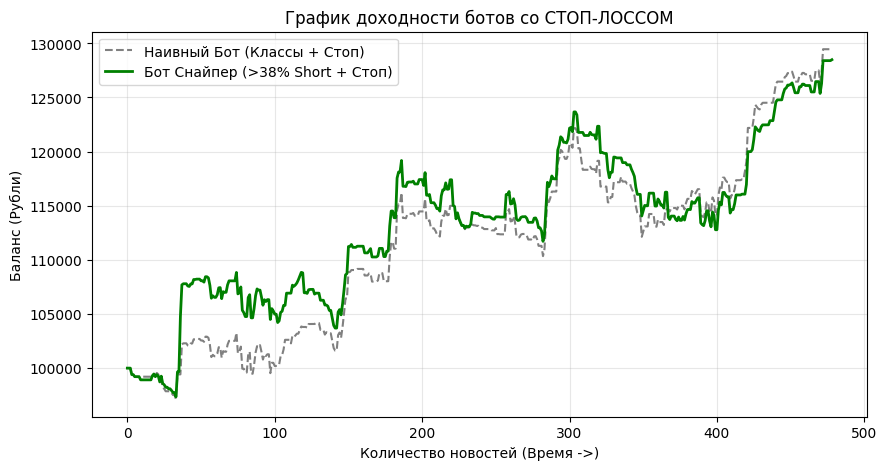

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_test = df.iloc[split_index:].copy()
real_returns = df_test['target_1h'].values

predictions = gb_model.predict(X_test)
probabilities = gb_model.predict_proba(X_test)
prob_short = probabilities[:, 0] 

START_BALANCE = 100000
COMMISSION = 0.10 # 0.1% комиссия брокера
STOP_LOSS = 2.0   # Максимальный убыток в сделке (2%)!

balance_naive = START_BALANCE
balance_sniper = START_BALANCE

equity_naive = [START_BALANCE]
equity_sniper = [START_BALANCE]

for i in range(len(real_returns)):
    real_pct = real_returns[i]
    
    # --- БОТ 1: НАИВНЫЙ ---
    if predictions[i] == -1: 
        profit_pct = (-1 * real_pct) - COMMISSION
        # Применяем стоп-лосс: если убыток больше 2%, мы теряем ровно 2%
        if profit_pct < -STOP_LOSS:
            profit_pct = -STOP_LOSS
        balance_naive *= (1 + profit_pct / 100)
        
    elif predictions[i] == 1: 
        profit_pct = real_pct - COMMISSION
        if profit_pct < -STOP_LOSS:
            profit_pct = -STOP_LOSS
        balance_naive *= (1 + profit_pct / 100)
        
    equity_naive.append(balance_naive)
    
    # --- БОТ 2: СНАЙПЕР (Честные 38%) ---
    if prob_short[i] >= 0.38: 
        profit_pct = (-1 * real_pct) - COMMISSION
        
        # МАГИЯ РИСК-МЕНЕДЖМЕНТА
        if profit_pct < -STOP_LOSS:
            profit_pct = -STOP_LOSS
            
        balance_sniper *= (1 + profit_pct / 100)
    
    equity_sniper.append(balance_sniper)

print("=== РЕЗУЛЬТАТЫ СИМУЛЯЦИИ СО СТОП-ЛОССОМ (2%) ===\n")
print(f"Стартовый капитал: {START_BALANCE:,.0f} руб.")
print(f"Наивный Бот: {balance_naive:,.0f} руб. | Доходность: {((balance_naive/START_BALANCE)-1)*100:.2f}%")
print(f"Бот Снайпер (>38%): {balance_sniper:,.0f} руб. | Доходность: {((balance_sniper/START_BALANCE)-1)*100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(equity_naive, label='Наивный Бот (Классы + Стоп)', color='gray', linestyle='--')
plt.plot(equity_sniper, label='Бот Снайпер (>38% Short + Стоп)', color='green', linewidth=2)
plt.title('График доходности ботов со СТОП-ЛОССОМ')
plt.xlabel('Количество новостей (Время ->)')
plt.ylabel('Баланс (Рубли)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import joblib

# Сохраняем векторизатор текстов (TF-IDF)
joblib.dump(tfidf, 'tfidf_vectorizer2.pkl')

# Сохраняем нашу лучшую модель Бустинга (обученную на 1-часовом таймфрейме)
joblib.dump(gb_model, 'gradient_boosting_model2.pkl')

print("✅ Готово! Модели tfidf_vectorizer.pkl и gradient_boosting_model.pkl успешно сохранены.")

✅ Готово! Модели tfidf_vectorizer.pkl и gradient_boosting_model.pkl успешно сохранены.
